# Experiment 01 — Idle vs Monte Carlo analysis

This notebook discovers every capture under `idle/` and `trials/`, keeps failed or incomplete runs visible for audit, and excludes them from scientific comparisons. It compares the valid idle baseline with Monte Carlo workloads, validates counter-derived energy against power integration, and is ready for future `run-now` / `green-window` pairs.

Important: Kepler pod energy is **CPU operational energy attributed to the workload**, not whole-server or facility energy.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except ImportError:
    display = print

ANALYSIS_DIR = Path.cwd().resolve()
if not (ANALYSIS_DIR / 'experiment_analysis.py').is_file():
    candidates = [
        ANALYSIS_DIR / 'kubernetes' / 'experiment-01' / 'analysis',
        ANALYSIS_DIR / 'analysis',
    ]
    ANALYSIS_DIR = next(path for path in candidates if (path / 'experiment_analysis.py').is_file())
sys.path.insert(0, str(ANALYSIS_DIR))

from experiment_analysis import (
    POWER_METRICS,
    build_idle_trial_comparison,
    build_inventory,
    find_experiment_root,
    integrate_power,
    load_idle_summary,
    load_metric_inventory,
    load_metrics,
    load_power_timeseries,
    load_trial_summary,
    paired_policy_comparison,
    repeatability_summary,
)

ROOT = find_experiment_root(ANALYSIS_DIR)
GENERATED = ROOT / 'analysis' / 'generated'
GENERATED.mkdir(parents=True, exist_ok=True)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
plt.style.use('seaborn-v0_8-whitegrid')
print(f'Experiment root: {ROOT}')

Experiment root: /Users/saur/Documents/CERN/green/kubernetes/experiment-01


## 1. Run inventory and quality gates

Every directory is listed, even if collection failed before producing `summary.json` or `result.json`. Only `complete=True` and `valid=True` runs are used below.

In [2]:
inventory = build_inventory(ROOT)
idle = load_idle_summary(ROOT)
trials = load_trial_summary(ROOT)

display(inventory[[
    'run_id', 'kind', 'status', 'complete', 'valid', 'policy',
    'started_at', 'duration_s', 'has_metrics_csv', 'metrics_size_mb',
    'blocking_conditions', 'warnings',
]])
print(f"Valid idle baselines: {int(idle['valid'].sum()) if not idle.empty else 0}")
print(f"Valid workload trials: {int(trials['valid'].sum()) if not trials.empty else 0}")

,run_id,kind,status,complete,valid,policy,started_at,duration_s,has_metrics_csv,metrics_size_mb,blocking_conditions,warnings
0,20260713T151537Z,idle,complete,True,False,idle,2026-07-13 15:15:38.455748+00:00,20.0052,True,1.5989,CrashLoopBackOff en el nodo: kube-system/cern-...,kubectl top pods -A --field-selector spec.node...
1,20260713T152539Z,idle,complete,True,True,idle,2026-07-13 15:25:40.452183+00:00,900.0078,True,46.7111,,la consulta node_power_supply no devolvió series
2,20260713T151205Z,idle,unknown,False,False,idle,NaT,NaN,False,0.0000,,
3,smoke-runner-02,trial,complete,True,True,calibration,2026-07-14 07:46:20.383862+00:00,28.4356,True,5.1900,,la consulta node_power_supply no devolvió series
4,calibration-01,trial,complete,True,True,calibration,2026-07-14 08:03:17.983832+00:00,929.3155,True,52.8210,,la consulta node_power_supply no devolvió series
5,smoke-runner-01,trial,failed,False,False,NaN,NaT,NaN,False,0.0000,,


Valid idle baselines: 1
Valid workload trials: 2


## 2. Normalized idle and trial summaries

In [3]:
idle_columns = [
    'run_id', 'valid', 'duration_s', 'sample_count', 'coverage',
    'total_w_mean', 'total_w_median', 'total_w_p95',
    'active_w_mean', 'idle_w_mean', 'cpu_ratio_mean',
    'observed_energy_j', 'counter_resets',
]
trial_columns = [
    'run_id', 'policy', 'valid', 'runtime_s', 'workers',
    'samples_per_worker', 'total_samples', 'pod_energy_j', 'pod_avg_w',
    'node_total_energy_j', 'node_active_energy_j', 'node_idle_energy_j',
    'node_total_w_mean', 'node_active_w_mean', 'cpu_ratio_mean',
    'energy_per_billion_samples_j', 'attribution_share_active',
    'node_counter_resets', 'scientific_ok',
]
display(idle[idle_columns])
display(trials[trial_columns])

,run_id,valid,duration_s,sample_count,coverage,total_w_mean,total_w_median,total_w_p95,active_w_mean,idle_w_mean,cpu_ratio_mean,observed_energy_j,counter_resets
0,20260713T151537Z,False,20.0052,3,1.0000,101.2969,101.7404,101.8229,0.8956,100.4013,0.0088,"2,149.4969",0
1,20260713T152539Z,True,900.0078,91,1.0000,102.1577,101.9107,104.7425,0.7510,101.4067,0.0074,"91,636.9730",0


,run_id,policy,valid,runtime_s,workers,samples_per_worker,total_samples,pod_energy_j,pod_avg_w,node_total_energy_j,node_active_energy_j,node_idle_energy_j,node_total_w_mean,node_active_w_mean,cpu_ratio_mean,energy_per_billion_samples_j,attribution_share_active,node_counter_resets,scientific_ok
0,calibration-01,calibration,True,929.3155,16,3150000000,50400000000,"42,413.3817",45.6394,"168,637.6283","43,398.3898","127,015.3879",182.2902,46.1908,0.2526,841.5354,0.9773,1,True
1,smoke-runner-02,calibration,True,28.4356,16,100000000,1600000000,"1,017.0851",35.7680,"4,957.8903",980.0870,"3,977.8033",181.1234,33.9199,0.1875,635.6782,1.0377,0,True


## 3. Metric coverage across all captures

This inventory demonstrates which query families and metrics are present without loading every large `metrics.csv` into memory at once.

In [4]:
metric_inventory = load_metric_inventory(ROOT)
coverage_by_query = (
    metric_inventory.groupby(['kind', 'query'], dropna=False)
    .agg(runs=('run_id', 'nunique'), metrics=('metric', 'nunique'),
         series=('series', 'sum'), samples=('samples', 'sum'))
    .reset_index()
    .sort_values(['kind', 'samples'], ascending=[True, False])
)
display(coverage_by_query)

,kind,query,runs,metrics,series,samples
6,idle,node_cpu_seconds,2,1,1024,48128
3,idle,kepler_container,2,2,264,11704
9,idle,node_frequency_temperature_pressure,2,5,174,8178
13,idle,node_network,2,6,144,6768
5,idle,kepler_pod,2,2,88,3784
0,idle,cadvisor_cpu_counters,2,1,38,1698
2,idle,cadvisor_memory,2,1,38,1698
4,idle,kepler_node,2,7,26,1222
8,idle,node_disk,2,5,20,940
11,idle,node_memory,2,5,10,470


## 4. Idle reference vs every valid workload

The reference is the median of valid idle baselines. Incremental node energy is estimated from the workload/idle mean-power difference over the exact workload runtime, avoiding sensitivity to counter resets and scrape-boundary extensions.

In [5]:
comparison, idle_reference = build_idle_trial_comparison(idle, trials)
display(pd.DataFrame([idle_reference], index=['valid-idle median']))
comparison_columns = [
    'run_id', 'runtime_s', 'total_samples',
    'idle_reference_total_w', 'node_total_w_mean',
    'total_power_delta_w', 'total_power_delta_pct',
    'idle_energy_for_runtime_j', 'estimated_incremental_node_energy_j',
    'pod_energy_j', 'pod_vs_incremental_energy_ratio',
    'energy_per_billion_samples_j',
]
display(comparison[comparison_columns])

,total_w_mean,total_w_median,active_w_mean,active_w_median,idle_w_mean,idle_w_median,cpu_ratio_mean,cpu_ratio_median
valid-idle median,102.1577,101.9107,0.7510,0.7355,101.4067,101.1257,0.0074,0.0072


,run_id,runtime_s,total_samples,idle_reference_total_w,node_total_w_mean,total_power_delta_w,total_power_delta_pct,idle_energy_for_runtime_j,estimated_incremental_node_energy_j,pod_energy_j,pod_vs_incremental_energy_ratio,energy_per_billion_samples_j
0,calibration-01,929.3155,50400000000,102.1577,182.2902,80.1325,78.4400,"94,936.7283","74,468.3633","42,413.3817",0.5695,841.5354
1,smoke-runner-02,28.4356,1600000000,102.1577,181.1234,78.9657,77.2978,"2,904.9196","2,245.4397","1,017.0851",0.4530,635.6782


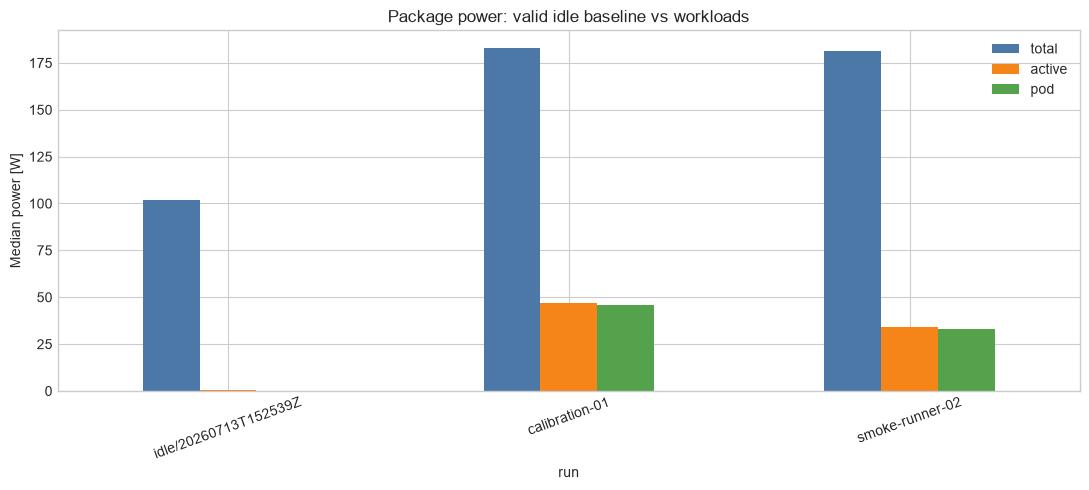

In [6]:
valid_idle = idle[idle['valid']].copy()
valid_trials = trials[trials['valid']].copy()
plot_rows = []
for row in valid_idle.itertuples():
    plot_rows.append({
        'run': f'idle/{row.run_id}', 'total': row.total_w_median,
        'active': row.active_w_median, 'pod': np.nan,
    })
for row in valid_trials.itertuples():
    plot_rows.append({
        'run': row.run_id, 'total': row.node_total_w_median,
        'active': row.node_active_w_median, 'pod': row.pod_w_median,
    })
power_bars = pd.DataFrame(plot_rows).set_index('run')
ax = power_bars.plot.bar(figsize=(11, 5), color=['#4c78a8', '#f58518', '#54a24b'])
ax.set_ylabel('Median power [W]')
ax.set_title('Package power: valid idle baseline vs workloads')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(GENERATED / '01_power_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Time series aligned to capture/workload start

The longest valid idle baseline and the largest valid trial are selected automatically. Change `SELECTED_IDLE` or `SELECTED_TRIAL` to inspect another run.

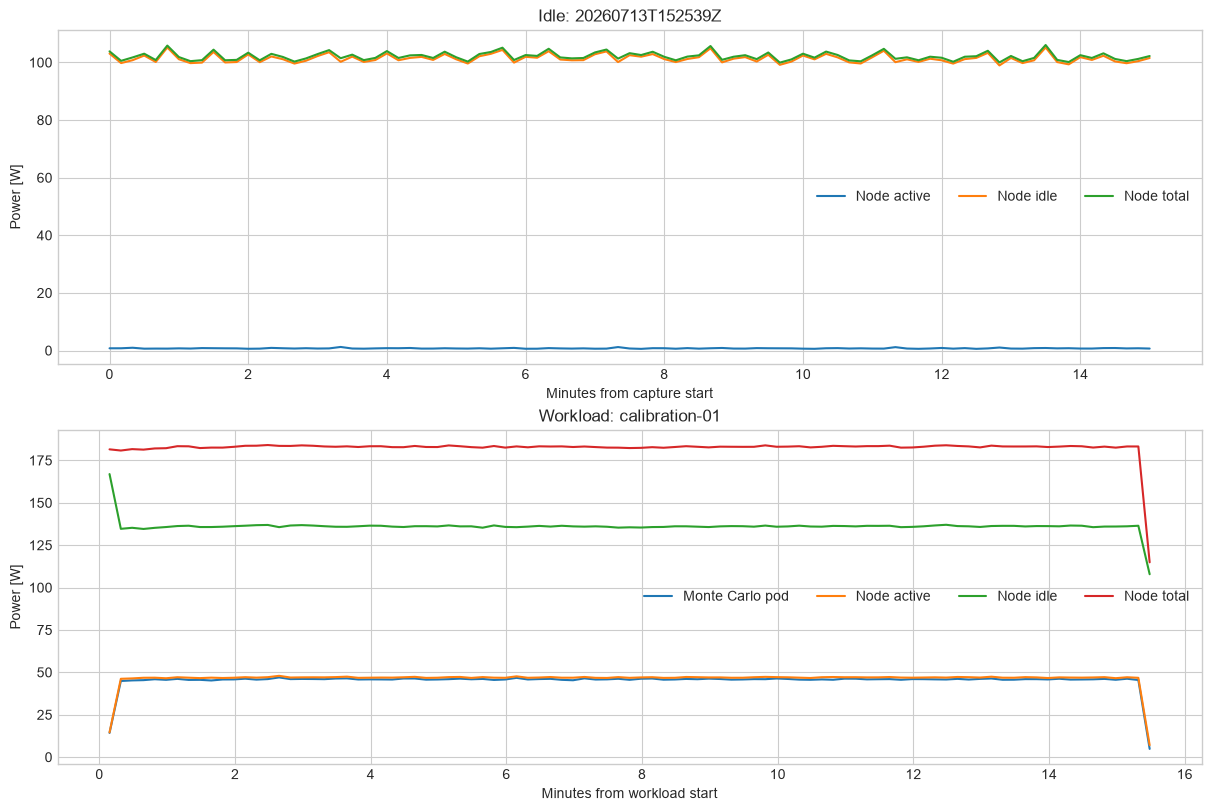

In [7]:
SELECTED_IDLE = valid_idle.sort_values('duration_s').iloc[-1]['run_id']
SELECTED_TRIAL = valid_trials.sort_values('total_samples').iloc[-1]['run_id']
idle_ts = load_power_timeseries(ROOT / 'idle' / SELECTED_IDLE, 'idle')
trial_ts = load_power_timeseries(ROOT / 'trials' / SELECTED_TRIAL, 'trial')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
for name, group in idle_ts.groupby('series'):
    axes[0].plot(group['elapsed_s'] / 60, group['value'], label=name, linewidth=1.5)
axes[0].set(title=f'Idle: {SELECTED_IDLE}', xlabel='Minutes from capture start', ylabel='Power [W]')
axes[0].legend(ncol=4)
for name, group in trial_ts.groupby('series'):
    axes[1].plot(group['elapsed_s'] / 60, group['value'], label=name, linewidth=1.5)
axes[1].set(title=f'Workload: {SELECTED_TRIAL}', xlabel='Minutes from workload start', ylabel='Power [W]')
axes[1].legend(ncol=4)
plt.savefig(GENERATED / '02_aligned_power_timeseries.png', dpi=160, bbox_inches='tight')
plt.show()

## 6. Energy cross-check by integrating watts

This is the preferred cross-check when a cumulative counter reports resets. Integration covers only the interval between the first and last observed sample, which is printed explicitly.

In [8]:
idle_integrated = integrate_power(idle_ts).assign(run_id=SELECTED_IDLE, kind='idle')
trial_integrated = integrate_power(trial_ts).assign(run_id=SELECTED_TRIAL, kind='trial')
integrated = pd.concat([idle_integrated, trial_integrated], ignore_index=True)
display(integrated[[
    'run_id', 'kind', 'series', 'samples', 'observed_span_s',
    'integrated_energy_j', 'mean_w', 'median_w', 'p95_w',
]])

,run_id,kind,series,samples,observed_span_s,integrated_energy_j,mean_w,median_w,p95_w
0,20260713T152539Z,idle,Node active,91,900.0000,676.2074,0.7510,0.7355,0.9345
1,20260713T152539Z,idle,Node idle,91,900.0000,"91,256.8823",101.4067,101.1257,103.9931
2,20260713T152539Z,idle,Node total,91,900.0000,"91,933.0898",102.1577,101.9107,104.7425
3,calibration-01,trial,Monte Carlo pod,93,920.0000,"41,873.3014",45.1277,45.8699,46.3622
4,calibration-01,trial,Node active,93,920.0000,"42,849.3856",46.1908,46.9355,47.3259
5,calibration-01,trial,Node idle,93,920.0000,"125,198.4728",136.0994,136.1168,136.7141
6,calibration-01,trial,Node total,93,920.0000,"168,047.8584",182.2902,183.1283,183.7557


## 7. Work scaling and energy efficiency

With only two workload sizes these trends are descriptive, not a fitted performance model. Add repeated calibrations before making statistical claims.

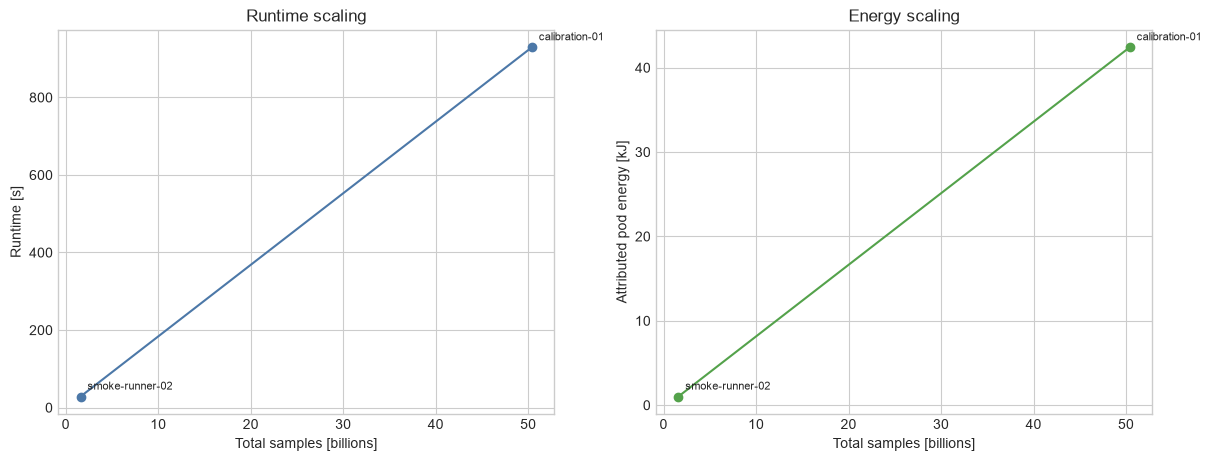

,run_id,total_samples,runtime_s,samples_per_second,pod_energy_j,energy_per_billion_samples_j
1,smoke-runner-02,1600000000,28.4356,"56,267,415.6155","1,017.0851",635.6782
0,calibration-01,50400000000,929.3155,"54,233,467.2152","42,413.3817",841.5354


In [9]:
scaling = valid_trials.sort_values('total_samples').copy()
scaling['samples_billions'] = scaling['total_samples'] / 1e9
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
axes[0].plot(scaling['samples_billions'], scaling['runtime_s'], 'o-', color='#4c78a8')
axes[0].set(xlabel='Total samples [billions]', ylabel='Runtime [s]', title='Runtime scaling')
axes[1].plot(scaling['samples_billions'], scaling['pod_energy_j'] / 1000, 'o-', color='#54a24b')
axes[1].set(xlabel='Total samples [billions]', ylabel='Attributed pod energy [kJ]', title='Energy scaling')
for ax, y in ((axes[0], 'runtime_s'), (axes[1], 'pod_energy_j')):
    for row in scaling.itertuples():
        y_value = getattr(row, y) / (1000 if y == 'pod_energy_j' else 1)
        ax.annotate(row.run_id, (row.samples_billions, y_value), xytext=(5, 5), textcoords='offset points', fontsize=8)
plt.savefig(GENERATED / '03_scaling.png', dpi=160, bbox_inches='tight')
plt.show()
display(scaling[[
    'run_id', 'total_samples', 'runtime_s', 'samples_per_second',
    'pod_energy_j', 'energy_per_billion_samples_j',
]])

## 8. Repeatability and coefficient of variation

Trials are grouped only when workers, samples, seed, and image digest are identical. The experiment criterion requires runtime and pod-energy CV below 10%; at least five equal calibrations are recommended.

In [10]:
repeatability = repeatability_summary(trials)
display(repeatability)
if repeatability.empty or repeatability['trials'].max() < 2:
    print('No repeated workload signature yet: CV cannot be estimated.')

,workers,samples_per_worker,base_seed,image_id,trials,runtime_mean_s,runtime_std_s,pod_energy_mean_j,pod_energy_std_j,runtime_cv_pct,pod_energy_cv_pct
0,16,100000000,20260713,docker.io/library/python@sha256:64695412729fbe...,1,28.4356,NaN,"1,017.0851",NaN,NaN,NaN
1,16,3150000000,20260713,docker.io/library/python@sha256:64695412729fbe...,1,929.3155,NaN,"42,413.3817",NaN,NaN,NaN


No repeated workload signature yet: CV cannot be estimated.


## 9. Inspect any raw metric

Set the run and query below to explore any captured metric family. This loads only one run, while Section 3 inventories all runs.

In [11]:
RAW_RUN = SELECTED_TRIAL
RAW_KIND = 'trial'
RAW_QUERY = 'node_memory_utilization_ratio'
raw_path = ROOT / ('trials' if RAW_KIND == 'trial' else 'idle') / RAW_RUN
raw = load_metrics(raw_path, queries=[RAW_QUERY])
display(raw.head(10))
display(raw.groupby(['query', 'metric'], dropna=False)['value'].agg(['count', 'mean', 'median', 'min', 'max']))

,query,metric,timestamp_utc,timestamp_unix,value,zone,path,namespace,pod_namespace,pod,pod_name,container,device,mode,cpu,timestamp
0,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:02:47.984000Z,"1,784,016,167.9840",0.0230,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:02:47.984000+00:00
1,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:02:57.984000Z,"1,784,016,177.9840",0.0230,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:02:57.984000+00:00
2,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:07.984000Z,"1,784,016,187.9840",0.0230,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:07.984000+00:00
3,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:17.984000Z,"1,784,016,197.9840",0.0230,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:17.984000+00:00
4,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:27.984000Z,"1,784,016,207.9840",0.0230,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:27.984000+00:00
5,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:37.984000Z,"1,784,016,217.9840",0.0233,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:37.984000+00:00
6,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:47.984000Z,"1,784,016,227.9840",0.0232,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:47.984000+00:00
7,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:03:57.984000Z,"1,784,016,237.9840",0.0232,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:03:57.984000+00:00
8,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:04:07.984000Z,"1,784,016,247.9840",0.0232,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:04:07.984000+00:00
9,node_memory_utilization_ratio,node_memory_utilization_ratio,2026-07-14T08:04:17.984000Z,"1,784,016,257.9840",0.0232,NaN,NaN,monitoring,NaN,monitoring-prometheus-node-exporter-rxjld,NaN,node-exporter,NaN,NaN,NaN,2026-07-14 08:04:17.984000+00:00


,,count,mean,median,min,max
query,metric,,,,,
node_memory_utilization_ratio,node_memory_utilization_ratio,100,0.0232,0.0232,0.0230,0.0233


## 10. Future paired run-now vs green-window comparison

Pairing is explicit to avoid guessing from trial names. Add rows to `PAIRS` after both policies exist. Energy/runtime comparisons work immediately; carbon comparison requires realized carbon intensity data, which current trial artifacts do not yet contain.

In [12]:
PAIRS = pd.DataFrame([
    # {'pair_id': '01', 'run_now': 'pair-01-now', 'green_window': 'pair-01-green'},
])
paired = paired_policy_comparison(trials, PAIRS)
if paired.empty:
    print('No run-now / green-window pairs have been declared yet.')
else:
    display(paired)

No run-now / green-window pairs have been declared yet.


## 11. Current descriptive conclusions and exports

In [13]:
formal = comparison.sort_values('total_samples').iloc[-1]
formal_trial = valid_trials.set_index('run_id').loc[formal['run_id']]
print(f"Selected formal trial: {formal['run_id']}")
print(f"Runtime: {formal['runtime_s']:.3f} s")
print(f"Idle total power reference: {formal['idle_reference_total_w']:.3f} W")
print(f"Workload total power mean: {formal['node_total_w_mean']:.3f} W")
print(f"Total power increase: {formal['total_power_delta_w']:.3f} W ({formal['total_power_delta_pct']:.1f}%)")
print(f"Attributed pod energy: {formal['pod_energy_j']/1000:.3f} kJ")
print(f"Energy per billion samples: {formal['energy_per_billion_samples_j']:.3f} J")
print(f"Pod / node-active attribution ratio: {formal_trial['attribution_share_active']:.3f}")
if formal_trial['node_counter_resets'] > 0:
    print('WARNING: node total counter reset observed; use the watts integration cross-check.')
print('Inference status: descriptive only; repeated calibrations and policy pairs are still required.')

inventory.to_csv(GENERATED / 'run_inventory.csv', index=False)
idle.to_csv(GENERATED / 'idle_summary.csv', index=False)
trials.to_csv(GENERATED / 'trial_summary.csv', index=False)
comparison.to_csv(GENERATED / 'idle_trial_comparison.csv', index=False)
metric_inventory.to_csv(GENERATED / 'metric_inventory.csv', index=False)
integrated.to_csv(GENERATED / 'integrated_power.csv', index=False)
print(f'Exported tables and figures to {GENERATED}')

Selected formal trial: calibration-01
Runtime: 929.315 s
Idle total power reference: 102.158 W
Workload total power mean: 182.290 W
Total power increase: 80.132 W (78.4%)
Attributed pod energy: 42.413 kJ
Energy per billion samples: 841.535 J
Pod / node-active attribution ratio: 0.977
Inference status: descriptive only; repeated calibrations and policy pairs are still required.
Exported tables and figures to /Users/saur/Documents/CERN/green/kubernetes/experiment-01/analysis/generated


### Interpretation limits

- There is currently one valid 15-minute idle baseline and one full-size workload calibration. This supports descriptive validation, not confidence intervals or hypothesis testing.
- The smoke and full trials have different amounts of scientific work and must not be treated as repeatability replicates.
- `kepler_pod_cpu_joules_total` is attributed CPU energy. Node package energy includes idle CPU energy, but not necessarily fans, NICs, disks, PSU losses, or cooling.
- A reset was observed in the full trial's node-total cumulative counter. The power integration section provides an independent energy cross-check.
- Carbon savings cannot be calculated until realized grid intensity is joined to interval energy and run-now/green-window trials are explicitly paired.